Libraries

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Loading Raw Data

In [2]:
df = pd.read_csv("sp500_adjusted_close_2y_full.csv", parse_dates=["Date"])
ordered_tickers = pd.read_csv("sp500_tickers.csv")['Symbol'].tolist()

df = df.pivot(index="Ticker", columns="Date", values="Adj Close")
df = df.loc[ordered_tickers]

print(df.head())

Date    2023-03-31  2023-04-03  2023-04-04  2023-04-05  2023-04-06  \
Ticker                                                               
AAPL        163.25      164.51      163.98      162.12      163.02   
MSFT        283.79      282.73      282.68      279.89      287.03   
NVDA         27.76       27.95       27.44       26.86       27.02   
AMZN        103.29      102.41      103.95      101.10      102.06   
META        210.95      212.07      213.71      210.49      215.09   

Date    2023-04-10  2023-04-11  2023-04-12  2023-04-13  2023-04-14  ...  \
Ticker                                                              ...   
AAPL        160.41      159.19      158.50      163.91      163.56  ...   
MSFT        284.86      278.40      279.05      285.30      281.66  ...   
NVDA         27.56       27.15       26.48       26.45       26.74  ...   
AMZN        102.17       99.92       97.83      102.40      102.51  ...   
META        213.74      212.85      213.00      219.32     

In [3]:
non_null_counts = df.notna().sum(axis=1).sort_values()
print(non_null_counts.head(10))  # Tickers with the least data

# Choose the ticker you want to inspect
view_ticker = 'SW'

# Check if the ticker exists in the pivoted DataFrame
if view_ticker in df.index:
    print("\n",df.loc[view_ticker])
else:
    print(f"{view_ticker} not found in dataset.")


Ticker
SW      183
GEV     250
SOLV    250
VLTO    372
KVUE    477
AAPL    500
WRB     500
HBAN    500
WAT     500
CDW     500
dtype: int64

 Date
2023-03-31      NaN
2023-04-03      NaN
2023-04-04      NaN
2023-04-05      NaN
2023-04-06      NaN
              ...  
2025-03-24    45.02
2025-03-25    45.57
2025-03-26    45.28
2025-03-27    45.40
2025-03-28    44.51
Name: SW, Length: 500, dtype: float64


Loading T-bill Daily Rates data

In [4]:
# Load T-bill Rates files
df_2024 = pd.read_csv("daily-treasury-rates-2024.csv")
df_2025 = pd.read_csv("daily-treasury-rates-2025.csv")

# Combine them
df_rates = pd.concat([df_2024, df_2025], ignore_index=True)

# Convert 'Date' column to datetime
df_rates['Date'] = pd.to_datetime(df_rates['Date'])

# Sort by date (just in case)
df_rates = df_rates.sort_values("Date").reset_index(drop=True)

# Preview
print(df_rates.head())
print("Shape:", df_rates.shape)

        Date  4 WEEKS BANK DISCOUNT  4 WEEKS COUPON EQUIVALENT  \
0 2024-01-02                   5.28                       5.39   
1 2024-01-03                   5.27                       5.38   
2 2024-01-04                   5.29                       5.40   
3 2024-01-05                   5.28                       5.39   
4 2024-01-08                   5.28                       5.39   

   8 WEEKS BANK DISCOUNT  8 WEEKS COUPON EQUIVALENT  13 WEEKS BANK DISCOUNT  \
0                   5.28                       5.41                    5.22   
1                   5.28                       5.41                    5.24   
2                   5.28                       5.41                    5.24   
3                   5.27                       5.40                    5.24   
4                   5.28                       5.41                    5.25   

   13 WEEKS COUPON EQUIVALENT  17 WEEKS BANK DISCOUNT  \
0                        5.38                    5.21   
1             

Pre-processing

In [5]:
p = 400
df_top = df.iloc[:p]

print(df_top.shape)
print(df_top.index[:5])  # Preview first 5 tickers

(400, 500)
Index(['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META'], dtype='object', name='Ticker')


In [6]:
# Step 1: Transpose (dates as index)
df_t = df_top.transpose()
df_t.index = pd.to_datetime(df_t.index)  # Ensure datetime index

# Step 2: Resample to weekly (Friday close)
df_weekly = df_t.resample("W-FRI").last()

n=26
n_dates = n+1
# Step 3: Get last 27 weeks
df_weekly_recent = df_weekly.tail(n_dates)

# Step 4: Transpose back (tickers as rows)
df_weekly_recent = df_weekly_recent.transpose()

# Done — preview
print("Shape:", df_weekly_recent.shape)        # (400, 27)
print("First few tickers:", df_weekly_recent.index[:5])
print("First few dates:", df_weekly_recent.columns[:5])
print("Last date:", df_weekly_recent.columns[-1])

Shape: (400, 27)
First few tickers: Index(['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META'], dtype='object', name='Ticker')
First few dates: DatetimeIndex(['2024-09-27', '2024-10-04', '2024-10-11', '2024-10-18',
               '2024-10-25'],
              dtype='datetime64[ns]', name='Date', freq='W-FRI')
Last date: 2025-03-28 00:00:00


Excess Return

In [7]:
# Get weekly prices as NumPy array
prices = df_weekly_recent.values  # shape: (400, 27)

# Compute returns row-wise
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]  # shape: (400, 26)

# Preview
print("Returns shape:", returns.shape)
print("Sample (first ticker):", returns[0])

Returns shape: (400, 26)
Sample (first ticker): [-0.00435567  0.00331418  0.03272407 -0.01526783 -0.03672586  0.01928783
 -0.00864541  0.02166852  0.03244491  0.0231999   0.02180814  0.0256193
  0.00432713 -0.04786338 -0.02673907 -0.02899531 -0.03129761  0.05931518
 -0.0354628   0.07573225  0.00388389 -0.01510894 -0.01145385 -0.10699795
  0.02238981 -0.00169515]


In [8]:
# Drop rows with missing values in the 26-week column
df_rates = df_rates.dropna(subset=["26 WEEKS COUPON EQUIVALENT"])

# Get the most recent available rate (last row)
latest_rate = df_rates["26 WEEKS COUPON EQUIVALENT"].iloc[-1]

print(latest_rate)

risk_free_weekly = latest_rate / 100 / 52  # convert to decimal and per week

excess_returns = returns - risk_free_weekly

4.22


De-mean Returns

In [9]:
# Step 1: Compute row-wise mean
row_means = excess_returns.mean(axis=1, keepdims=True)  # shape: (400, 1)

# Step 2: Subtract row mean from each row (using Broadcasting automatically does what we want)
excess_returns_demeaned = excess_returns - row_means

# Check result
print("Shape:", excess_returns_demeaned.shape)
print("First row mean (should be ~0):", excess_returns_demeaned[0].mean())

Shape: (400, 26)
First row mean (should be ~0): -7.506015040284261e-20


Compute Covariance Matrix Y

In [10]:
# excess_returns_demeaned shape: (400, 26)
cov_matrix = (excess_returns_demeaned @ excess_returns_demeaned.T) / n

print("Covariance matrix shape:", cov_matrix.shape)
print("Sample (top-left 5x5):")
print(cov_matrix[:5, :5])

Covariance matrix shape: (400, 400)
Sample (top-left 5x5):
[[ 1.30697932e-03  3.69248044e-05 -5.27572401e-04  1.56842720e-04
   3.15223681e-04]
 [ 3.69248044e-05  6.10957377e-04  7.41021980e-04  3.49209521e-04
   2.23445318e-04]
 [-5.27572401e-04  7.41021980e-04  3.73059756e-03  5.24824141e-04
   6.06879754e-04]
 [ 1.56842720e-04  3.49209521e-04  5.24824141e-04  1.18443741e-03
   8.57105312e-04]
 [ 3.15223681e-04  2.23445318e-04  6.06879754e-04  8.57105312e-04
   1.63144034e-03]]


Ledoit-Wolf Single-Factor Estimator

In [11]:
eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # symmetric eigendecomposition

# Step 1: Leading eigenvalue and eigenvector
lambda_sq = eigvals[-1]             # largest eigenvalue (λ²)
h = eigvecs[:, -1]                  # unit eigenvector corresponding to λ²

# Step 2: Compute ℓ²
trace_S = np.trace(cov_matrix)
ell_sq = (trace_S - lambda_sq) / (n - 1)

# Step 3: Build the estimator
term1 = (lambda_sq - ell_sq) * np.outer(h, h)
term2 = (n / p) * ell_sq * np.eye(p)

Sigma = term1 + term2

# Preview
print("Estimated Σ shape:", Sigma.shape)
print("ℓ² =", ell_sq)
print("λ² =", lambda_sq)

Estimated Σ shape: (400, 400)
ℓ² = 0.020906032520835244
λ² = 0.18370945375202913


James-Stein Shrinkage

In [13]:
# Eigen decomposition (cov_matrix is symmetric)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
lambda_sq = eigvals[-1]
h = eigvecs[:, -1]  # unit eigenvector (length p)

# Average of h
mh = np.mean(h)
# ν² = (tr(S) - λ²) / (p(n-1))
trace_S = np.trace(cov_matrix)
nu_sq = (trace_S - lambda_sq) / (p * (n - 1))

# s²(h) = λ² * Var(h) * p
s_sq_h = lambda_sq * np.var(h) * p

# Shrinkage constant
c_JSE = 1 - (nu_sq / s_sq_h)

# Compute h_JSE
h_JSE = mh + c_JSE * (h - mh)

# ℓ² (as in Ledoit-Wolf): average of smaller eigenvalues
ell_sq = (trace_S - lambda_sq) / (n - 1)

# Final JSE covariance estimator:
# Σ_JSE = (λ² - ℓ²) * h_JSE h_JSEᵀ / |h_JSE|² + (n/p) * ℓ² * I
norm_sq_h_JSE = np.sum(h_JSE ** 2)
term1 = (lambda_sq - ell_sq) * np.outer(h_JSE, h_JSE) / norm_sq_h_JSE
term2 = (n / p) * ell_sq * np.eye(p)
Sigma_JSE = term1 + term2

# Output summary
print("JSE Covariance Estimate Shape:", Sigma_JSE.shape)
print("λ² =", lambda_sq)
print("ℓ² =", ell_sq)
print("ν² =", nu_sq)
print("c_JSE =", c_JSE)

JSE Covariance Estimate Shape: (400, 400)
λ² = 0.18370945375202913
ℓ² = 0.020906032520835244
ν² = 5.226508130208811e-05
c_JSE = 0.9991811315156885


GMV Portfolio (For PCA)

In [93]:
# Vector of ones
e = np.ones((p, 1))

# Invert Sigma
Sigma_inv = np.linalg.inv(Sigma)

# Minimum variance weights
numerator = Sigma_inv @ e
denominator = e.T @ Sigma_inv @ e
h_c = numerator / denominator  # shape: (p, 1)

# Mean return vector from excess_returns
f = excess_returns.mean(axis=1, keepdims=True)  # shape: (p, 1)

# Weekly portfolio return and variance
f_c_weekly = float(h_c.T @ f)
sigma_c_sq_weekly = float(h_c.T @ Sigma @ h_c)

# Annualize
f_c_annual = f_c_weekly * 52
sigma_c_sq_annual = sigma_c_sq_weekly * 52
sigma_c_annual = np.sqrt(sigma_c_sq_annual)

In [16]:
# Output
print("Annualized minimum variance portfolio return:", f_c_annual)
print("Annualized variance:", sigma_c_sq_annual)
print("Annualized standard deviation:", sigma_c_annual)
print("Sum of the holdings vector (Fully invested condition):", np.sum(h_c))

Annualized minimum variance portfolio return: -0.1468154344196718
Annualized variance: 0.0005006819390292452
Annualized standard deviation: 0.02237592319948487
Sum of the holdings vector (Fully invested condition): 1.0000000000000002


GMV Portfolio (for JSE)

In [96]:
# === JSE GMV Portfolio ===
Sigma_JSE_inv = np.linalg.inv(Sigma_JSE)

numerator_jse = Sigma_JSE_inv @ e
denominator_jse = e.T @ Sigma_JSE_inv @ e
h_jse = numerator_jse / denominator_jse  # GMV weights (JSE)

f_c_weekly_jse = float(h_jse.T @ f)
sigma_c_sq_weekly_jse = float(h_jse.T @ Sigma_JSE @ h_jse)

f_c_annual_jse = f_c_weekly_jse * 52
sigma_c_sq_annual_jse = sigma_c_sq_weekly_jse * 52
sigma_c_annual_jse = np.sqrt(sigma_c_sq_annual_jse)

print("\nJSE GMV:")
print("Return (annual):", f_c_annual_jse)
print("Variance (annual):", sigma_c_sq_annual_jse)
print("Std Dev (annual):", sigma_c_annual_jse)


JSE GMV:
Return (annual): -0.14690743003114895
Variance (annual): 0.0005012051132356088
Std Dev (annual): 0.022387610708505916


In [98]:
# LaTeX table with 6 decimal places
print(r"\begin{tabular}{lrr}")
print(r"\toprule")
print(r"\textbf{Metric} & \textbf{PCA Estimate} & \textbf{JSE Estimate} \\")
print(r"\midrule")
print(f"Minimum Variance Portfolio Return & {f_c_annual:.6f} & {f_c_annual_jse:.6f} \\\\")
print(f"Minimum Variance Portfolio Variance & {sigma_c_sq_annual:.6f} & {sigma_c_sq_annual_jse:.6f} \\\\")
print(f"Minimum Variance Portfolio Std Dev & {sigma_c_annual:.6f} & {sigma_c_annual_jse:.6f} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")


\begin{tabular}{lrr}
\toprule
\textbf{Metric} & \textbf{PCA Estimate} & \textbf{JSE Estimate} \\
\midrule
Minimum Variance Portfolio Return & -0.146815 & -0.146907 \\
Minimum Variance Portfolio Variance & 0.000501 & 0.000501 \\
Minimum Variance Portfolio Std Dev & 0.022376 & 0.022388 \\
\bottomrule
\end{tabular}


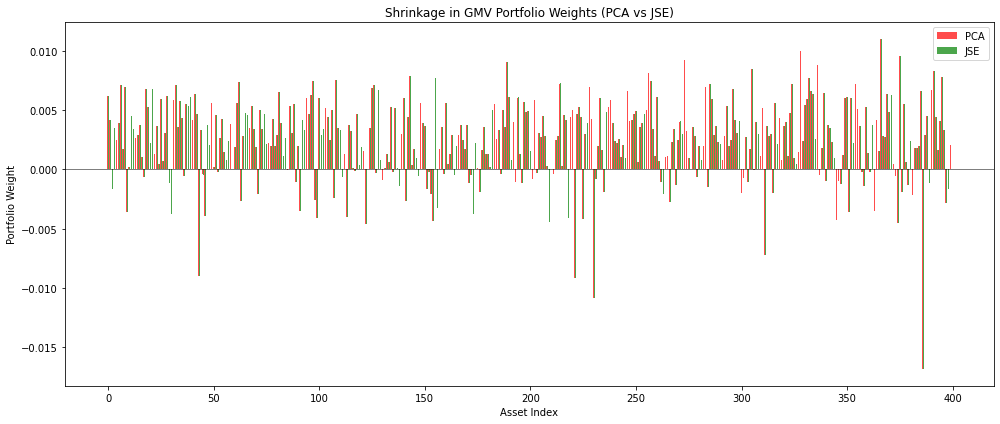

In [99]:
# Convert weights to 1D for plotting
w_pca = h_c.flatten()
w_jse = h_jse.flatten()

# Create index for assets
asset_indices = np.arange(len(w_pca))

# Plot
plt.figure(figsize=(14, 6))
plt.bar(asset_indices - 0.2, w_pca, width=0.4, label='PCA', color='red', alpha=0.7)
plt.bar(asset_indices + 0.2, w_jse, width=0.4, label='JSE', color='green', alpha=0.7)

plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel("Asset Index")
plt.ylabel("Portfolio Weight")
plt.title("Shrinkage in GMV Portfolio Weights (PCA vs JSE)")
plt.legend()
plt.tight_layout()
plt.show()

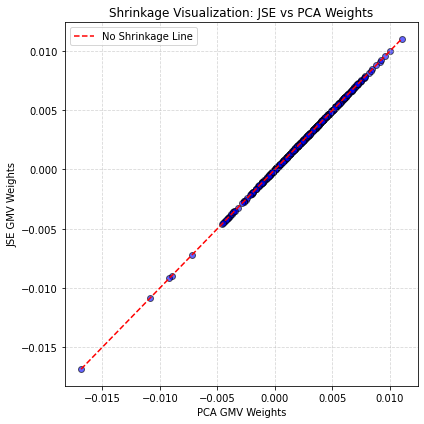

In [100]:
plt.figure(figsize=(6, 6))
plt.scatter(w_pca, w_jse, color='blue', alpha=0.6, edgecolor='k')
plt.plot([w_pca.min(), w_pca.max()], [w_pca.min(), w_pca.max()], 'r--', label='No Shrinkage Line')

plt.xlabel("PCA GMV Weights")
plt.ylabel("JSE GMV Weights")
plt.title("Shrinkage Visualization: JSE vs PCA Weights")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


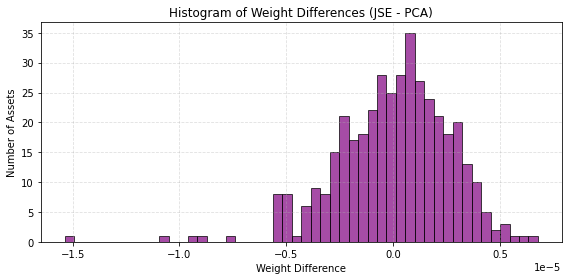

In [101]:
diff = w_jse - w_pca
plt.figure(figsize=(8, 4))
plt.hist(diff, bins=50, color='purple', edgecolor='k', alpha=0.7)
plt.title("Histogram of Weight Differences (JSE - PCA)")
plt.xlabel("Weight Difference")
plt.ylabel("Number of Assets")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Visualization

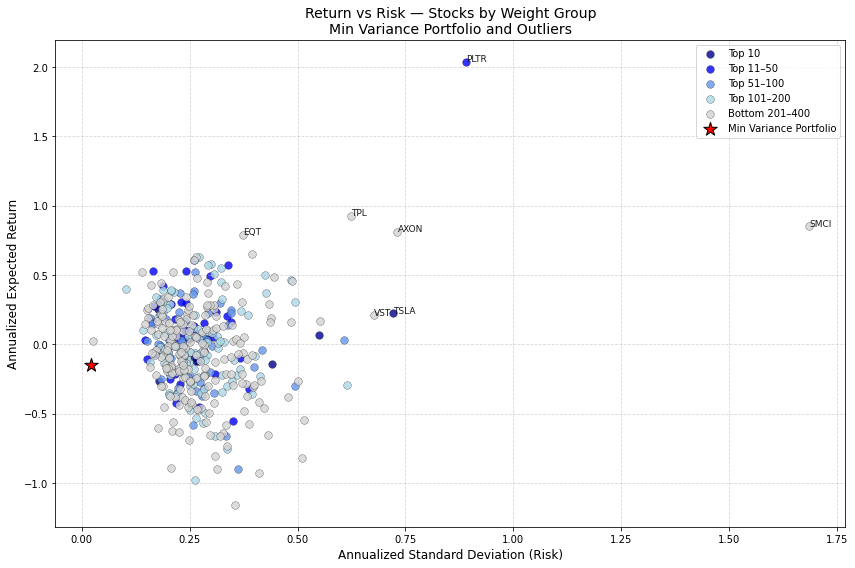

In [21]:
# Step 1: Individual metrics
individual_returns_annual = excess_returns.mean(axis=1) * 52
individual_std_annual = np.sqrt(np.diag(cov_matrix) * 52)

# Get tickers (ordered to match top 400)
top_400_tickers = ordered_tickers[:400]
tickers = np.array(top_400_tickers)

# Step 2: Group assignments
groups = {
    "Top 10": np.arange(0, 10),
    "Top 11–50": np.arange(10, 50),
    "Top 51–100": np.arange(50, 100),
    "Top 101–200": np.arange(100, 200),
    "Bottom 201–400": np.arange(200, 400)
}
colors = ['darkblue', 'blue', 'cornflowerblue', 'lightblue', 'lightgray']

# Step 3: Plot
plt.figure(figsize=(12, 8))

for (label, indices), color in zip(groups.items(), colors):
    plt.scatter(
        individual_std_annual[indices],
        individual_returns_annual[indices],
        color=color, label=label,
        alpha=0.8, edgecolor='k', linewidth=0.3, s=60
    )

# Step 4: Plot min variance portfolio
plt.scatter(
    sigma_c_annual, f_c_annual,
    color='red', marker='*', s=200, label='Min Variance Portfolio', edgecolor='black'
)

# Rank indices by return and risk
top_return_indices = np.argsort(individual_returns_annual)[-5:]
top_risk_indices = np.argsort(individual_std_annual)[-5:]

# Combine and remove duplicates
label_indices = np.unique(np.concatenate([top_return_indices, top_risk_indices]))

# Label the chosen outliers
for i in label_indices:
    plt.text(
        individual_std_annual[i] + 0.001,
        individual_returns_annual[i] + 0.001,
        tickers[i],
        fontsize=9, alpha=0.9
    )

# Final plot formatting
plt.xlabel("Annualized Standard Deviation (Risk)", fontsize=12)
plt.ylabel("Annualized Expected Return", fontsize=12)
plt.title("Return vs Risk — Stocks by Weight Group\nMin Variance Portfolio and Outliers", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

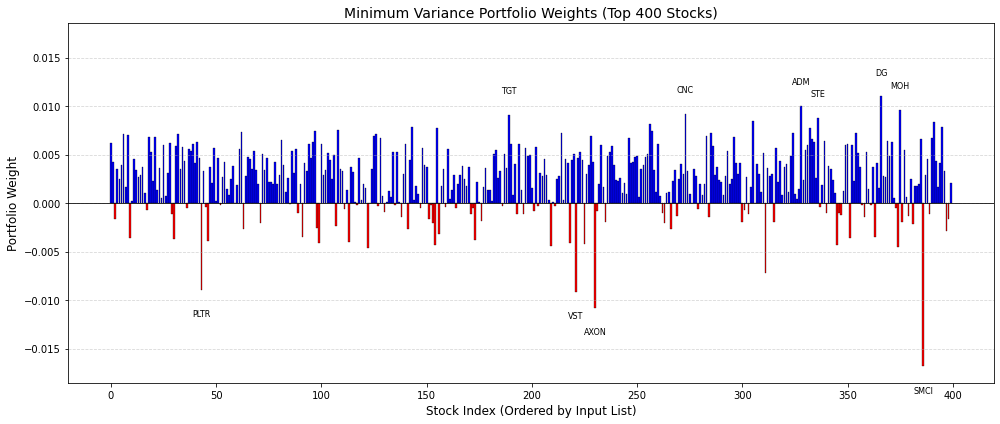

In [61]:
# Flatten weights just in case
h_c = h_c.flatten()
x = np.arange(len(h_c))

# Color: blue for long, red for short
colors = ['blue' if w > 0 else 'red' for w in h_c]

# Create the bar chart
plt.figure(figsize=(14, 6))
bars = plt.bar(x, h_c, color=colors, edgecolor='black', linewidth=0.3)

# Label the top 10 absolute weights
top_10_indices = np.argsort(np.abs(h_c))[-10:]
for i in top_10_indices:
    plt.text(
        x[i],
        h_c[i] + (0.002 if h_c[i] > 0 else -0.002),
        tickers[i],
        ha='center',
        va='bottom' if h_c[i] > 0 else 'top',
        fontsize=8,
        rotation=0  # horizontal
    )
# Styling
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Minimum Variance Portfolio Weights (Top 400 Stocks)", fontsize=14)
plt.xlabel("Stock Index (Ordered by Input List)", fontsize=12)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
# Symmetric y-limits based on max absolute weight
ymax = np.max(np.abs(h_c))
plt.ylim(-ymax * 1.1, ymax * 1.1)  # Add 10% headroo
plt.show()


In [63]:
# Compute individual metrics
individual_returns_annual = excess_returns.mean(axis=1) * 52
individual_variances_annual = np.diag(cov_matrix) * 52

# Build summary dictionary
summary_data = {
    "Metric": [
        "Minimum Variance Portfolio Return",
        "Minimum Variance Portfolio Variance",
        "Minimum Variance Portfolio Std Dev",
        "Sum of Portfolio Weights",
        "Max Individual Stock Return",
        "Min Individual Stock Return",
        "Max Individual Stock Variance",
        "Min Individual Stock Variance"
    ],
    "Value": [
        f_c_annual,
        sigma_c_sq_annual,
        sigma_c_annual,
        np.sum(h_c),
        individual_returns_annual.max(),
        individual_returns_annual.min(),
        individual_variances_annual.max(),
        individual_variances_annual.min()
    ]
}

# Create the DataFrame
summary_df = pd.DataFrame(summary_data)

# Convert to LaTeX code. The float_format parameter formats numbers to 4 decimal places.
latex_table = summary_df.to_latex(index=False, float_format="%.4f")
print(latex_table)


\begin{tabular}{lr}
\toprule
                             Metric &   Value \\
\midrule
  Minimum Variance Portfolio Return & -0.1468 \\
Minimum Variance Portfolio Variance &  0.0005 \\
 Minimum Variance Portfolio Std Dev &  0.0224 \\
           Sum of Portfolio Weights &  1.0000 \\
        Max Individual Stock Return &  2.0382 \\
        Min Individual Stock Return & -1.1562 \\
      Max Individual Stock Variance &  2.8417 \\
      Min Individual Stock Variance &  0.0007 \\
\bottomrule
\end{tabular}



C:\Users\DELL\AppData\Local\Temp\ipykernel_19940\2221107828.py:33: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = summary_df.to_latex(index=False, float_format="%.4f")


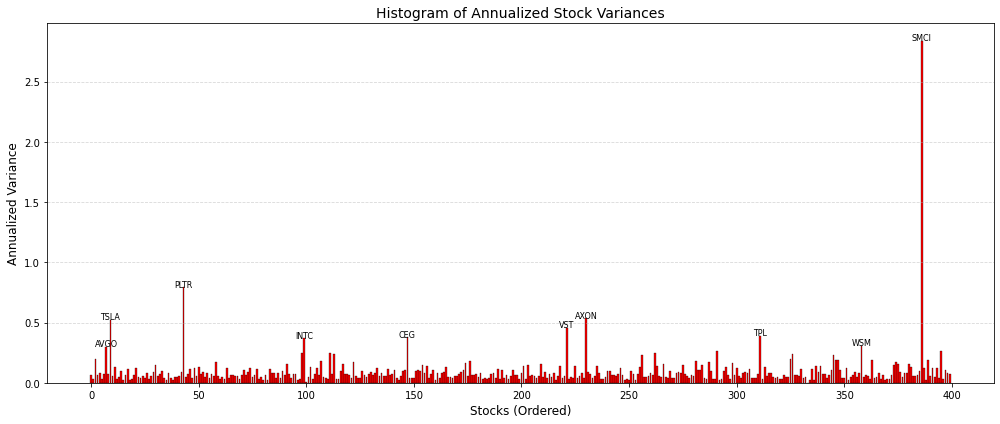

In [64]:
# Sort variances and get top 10 outlier indices
top_var_indices = np.argsort(individual_variances_annual)[-10:]

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(individual_variances_annual)), individual_variances_annual, color='red', edgecolor='black', linewidth=0.3)

# Label the top 10 variance outliers
for i in top_var_indices:
    plt.text(i, individual_variances_annual[i] + 0.005, tickers[i], ha='center', fontsize=8)

plt.title("Histogram of Annualized Stock Variances", fontsize=14)
plt.xlabel("Stocks (Ordered)", fontsize=12)
plt.ylabel("Annualized Variance", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

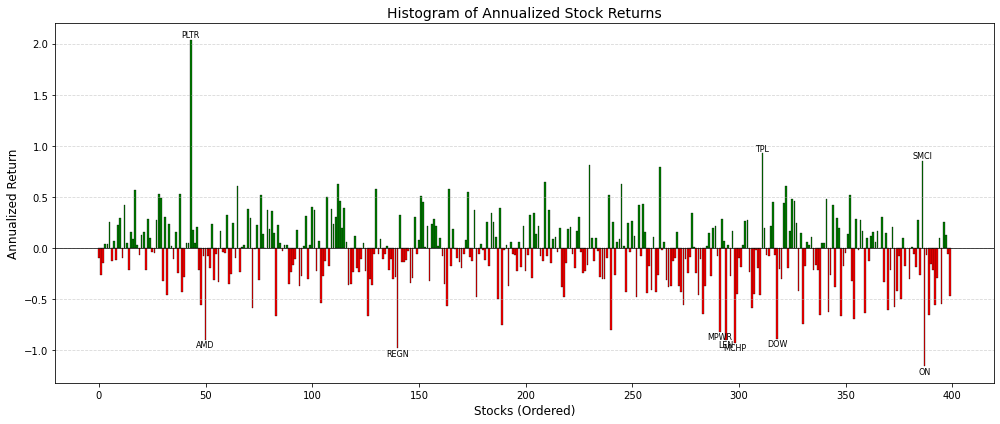

In [66]:
# Color each bar based on sign of return
colors = ['green' if val >= 0 else 'red' for val in individual_returns_annual]

# Identify top 10 absolute return outliers (positive or negative)
top_ret_indices = np.argsort(np.abs(individual_returns_annual))[-10:]

# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(
    range(len(individual_returns_annual)),
    individual_returns_annual,
    color=colors,
    edgecolor='black',
    linewidth=0.3
)

# Label top 10 absolute return tickers
for i in top_ret_indices:
    offset = 0.005 if individual_returns_annual[i] >= 0 else -0.005
    va = 'bottom' if individual_returns_annual[i] >= 0 else 'top'
    plt.text(i, individual_returns_annual[i] + offset, tickers[i], ha='center', va=va, fontsize=8)

# Style
plt.title("Histogram of Annualized Stock Returns", fontsize=14)
plt.xlabel("Stocks (Ordered)", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.axhline(0, color='black', linewidth=0.7)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


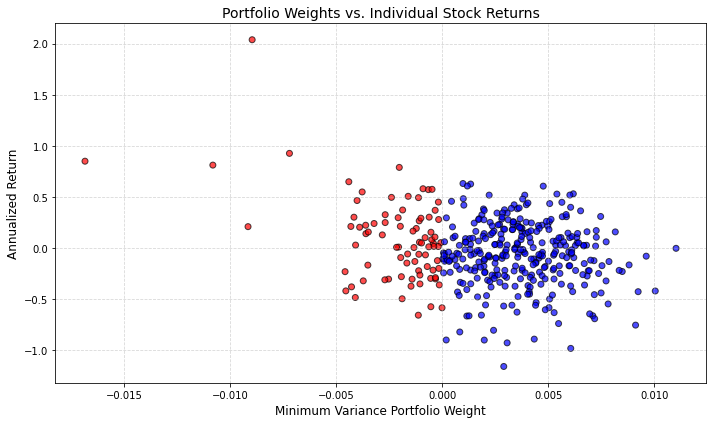

In [67]:
# Choose one: returns or volatility
y_metric = individual_returns_annual  # or: np.sqrt(individual_variances_annual)

plt.figure(figsize=(10, 6))
plt.scatter(h_c, y_metric, c=['blue' if w >= 0 else 'red' for w in h_c], edgecolor='black', alpha=0.7)
plt.xlabel("Minimum Variance Portfolio Weight", fontsize=12)
plt.ylabel("Annualized Return" if y_metric is individual_returns_annual else "Annualized Volatility", fontsize=12)
plt.title("Portfolio Weights vs. Individual Stock " + ("Returns" if y_metric is individual_returns_annual else "Volatility"), fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

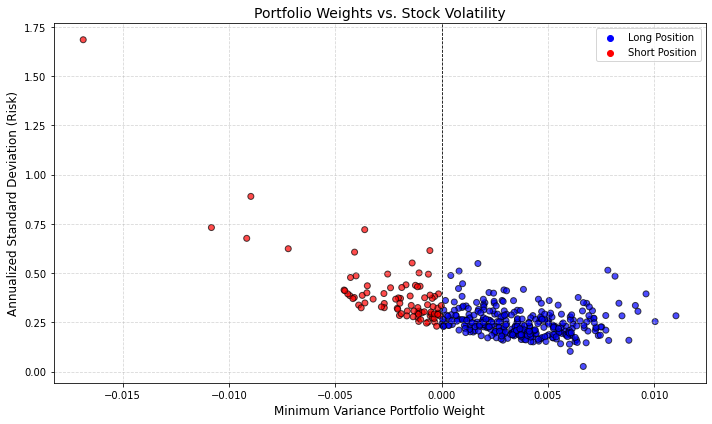

In [72]:
# x = weights, y = annualized std dev (risk)
x_weights = h_c
y_risk = np.sqrt(individual_variances_annual)

# Define color mapping
colors = ['blue' if w >= 0 else 'red' for w in x_weights]

# Create plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x_weights,
    y_risk,
    c=colors,
    edgecolor='black',
    alpha=0.7
)

# Add dummy scatter points for legend
plt.scatter([], [], color='blue', label='Long Position')
plt.scatter([], [], color='red', label='Short Position')

# Labels and style
plt.xlabel("Minimum Variance Portfolio Weight", fontsize=12)
plt.ylabel("Annualized Standard Deviation (Risk)", fontsize=12)
plt.title("Portfolio Weights vs. Stock Volatility", fontsize=14)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

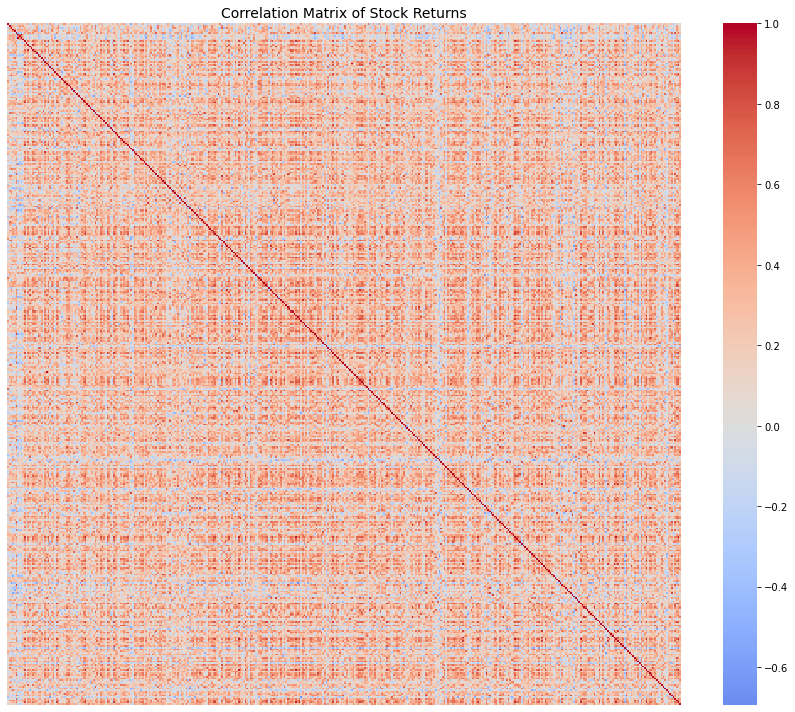

In [69]:
# Build correlation matrix
stddev = np.sqrt(np.diag(cov_matrix))
corr_matrix = cov_matrix / np.outer(stddev, stddev)
np.fill_diagonal(corr_matrix, 1.0)

# Optional: convert to DataFrame for labels
corr_df = pd.DataFrame(corr_matrix, index=tickers, columns=tickers)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title("Correlation Matrix of Stock Returns", fontsize=14)
plt.tight_layout()
plt.show()

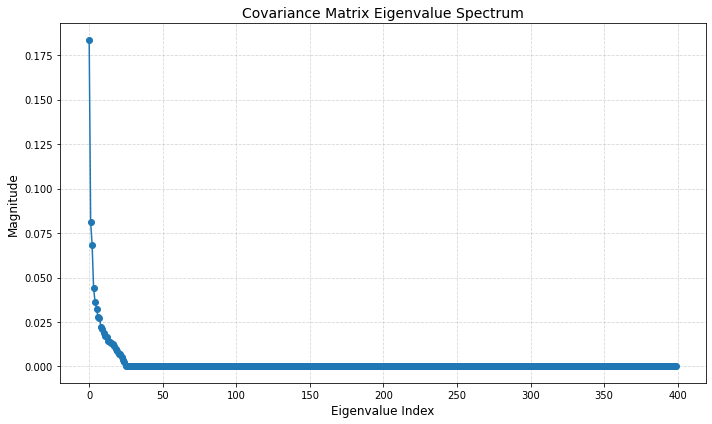

In [70]:
# Get eigenvalues of the covariance matrix
eigenvalues = np.linalg.eigvalsh(cov_matrix)
eigenvalues = np.sort(eigenvalues)[::-1]  # descending

plt.figure(figsize=(10, 6))
plt.plot(eigenvalues, marker='o')
plt.title("Covariance Matrix Eigenvalue Spectrum", fontsize=14)
plt.xlabel("Eigenvalue Index", fontsize=12)
plt.ylabel("Magnitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Daily Data GMV Calculation (500 days, 400 stocks)

In [44]:
# df is your pivoted price matrix: rows = tickers, columns = dates
non_null_counts = df.notna().sum(axis=1)

# Keep only stocks with at least 500 non-null days
df_filtered = df[non_null_counts >= 500]

print(f"Stocks with ≥500 days of data: {df_filtered.shape[0]}")

Stocks with ≥500 days of data: 498


In [45]:
# Re-load full ticker list (ordered by weight)
ordered_tickers = pd.read_csv("sp500_tickers.csv")["Symbol"].tolist()

# Find tickers that meet the 500-day threshold and preserve weight order
eligible_tickers = df_filtered.index.tolist()
top_400_filtered = [t for t in ordered_tickers if t in eligible_tickers][:400]

# Final clean dataset (400 x 500)
df_400 = df_filtered.loc[top_400_filtered].iloc[:, -500:]  # get most recent 500 days


In [46]:
df_rf = pd.read_csv("daily-treasury-rates-2024.csv")
df_rf["Date"] = pd.to_datetime(df_rf["Date"])
df_rf = df_rf.dropna(subset=["26 WEEKS COUPON EQUIVALENT"])
df_rf = df_rf.sort_values("Date")

latest_rf = df_rf["26 WEEKS COUPON EQUIVALENT"].iloc[-1]
risk_free_daily = latest_rf / 100 / 252

In [48]:
# Daily returns (same as before)
returns = df_400.pct_change(axis=1).iloc[:, 1:]  # shape: (400, 499)

# Excess returns (numpy array)
excess_returns = returns.values - risk_free_daily

# Mean excess return per stock
f = excess_returns.mean(axis=1, keepdims=True)

# Covariance matrix of excess returns
cov_matrix = np.cov(excess_returns)
print(cov_matrix.shape[0],cov_matrix.shape[1])

400 400


In [49]:
n = excess_returns.shape[1]
p = cov_matrix.shape[0]

print(p,n)
# Step 1: Eigendecomposition (for symmetric matrices)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
lambda_sq = eigvals[-1]       # largest eigenvalue (λ²)
h = eigvecs[:, -1]            # unit eigenvector corresponding to λ²

# Step 2: Compute ℓ² = (tr(S) - λ²) / (n - 1)
trace_S = np.trace(cov_matrix)
ell_sq = (trace_S - lambda_sq) / (n - 1)

# Step 3: Build the Ledoit-Wolf-like estimator
term1 = (lambda_sq - ell_sq) * np.outer(h, h)
term2 = (n / p) * ell_sq * np.eye(p)
Sigma = term1 + term2  # this is your updated LW-type shrinkage estimator

# Preview
print("Estimated Σ shape:", Sigma.shape)
print("ℓ² =", ell_sq)
print("λ² =", lambda_sq)

Sigma_PCA = Sigma

400 499
Estimated Σ shape: (400, 400)
ℓ² = 0.00019764257368142565
λ² = 0.027073565038481018


In [50]:
# ========== Step 1: James-Stein Eigenvector Shrinkage Estimator ==========
p = excess_returns.shape[0]   # 400 assets
n = excess_returns.shape[1]   # 499 days

# Sample covariance matrix
cov_matrix = np.cov(excess_returns)

# Eigendecomposition
eigvals, eigvecs = np.linalg.eigh(cov_matrix)
lambda_sq = eigvals[-1]
h = eigvecs[:, -1]

# Mean of eigenvector
mh = np.mean(h)

# ν² = (tr(S) - λ²) / (p(n-1))
trace_S = np.trace(cov_matrix)
nu_sq = (trace_S - lambda_sq) / (p * (n - 1))

# s²(h) = λ² * Var(h) * p
s_sq_h = lambda_sq * np.var(h) * p

# Shrinkage constant
c_JSE = 1 - (nu_sq / s_sq_h)

# h_JSE
h_JSE = mh + c_JSE * (h - mh)

# ℓ² (same as before)
ell_sq = (trace_S - lambda_sq) / (n - 1)

# Final Σ_JSE
norm_sq = np.sum(h_JSE ** 2)
term1 = (lambda_sq - ell_sq) * np.outer(h_JSE, h_JSE) / norm_sq
term2 = (n / p) * ell_sq * np.eye(p)
Sigma_JSE = term1 + term2

In [70]:
def compute_gmv(Sigma, excess_returns, scale=252):
    """
    Compute GMV portfolio stats from a covariance matrix.

    Parameters:
        Sigma : np.ndarray
            Covariance matrix (p x p)
        excess_returns : np.ndarray
            Excess returns (p x t)
        scale : int
            Annualization factor (252 for daily, 52 for weekly)

    Returns:
        weights : np.ndarray
            GMV weights (p x 1)
        annual_return : float
        annual_variance : float
        annual_std_dev : float
    """
    p = Sigma.shape[0]
    e = np.ones((p, 1))
    Sigma_inv = np.linalg.inv(Sigma)

    # GMV weights
    numerator = Sigma_inv @ e
    denominator = e.T @ Sigma_inv @ e
    h_c = numerator / denominator  # shape (p, 1)

    # Mean return vector (p x 1)
    f = excess_returns.mean(axis=1, keepdims=True)

    # Portfolio return and variance
    f_c = float(h_c.T @ f)
    sigma_c_sq = float(h_c.T @ Sigma @ h_c)

    # Annualize
    f_c_annual = f_c * scale
    sigma_c_sq_annual = sigma_c_sq * scale
    sigma_c_annual = np.sqrt(sigma_c_sq_annual)

    return h_c, f_c_annual, sigma_c_sq_annual, sigma_c_annual


In [71]:
# For Ledoit-Wolf (PCA-style)
weights_pca, ret_pca, var_pca, std_pca = compute_gmv(Sigma_PCA, excess_returns)

# For James–Stein Estimator
weights_jse, ret_jse, var_jse, std_jse = compute_gmv(Sigma_JSE, excess_returns)
print("PCA - Return:", ret_pca, " | Std Dev:", std_pca)
print("JSE - Return:", ret_jse, " | Std Dev:", std_jse)

PCA - Return: 0.01794322447398958  | Std Dev: 0.02471304444089874
JSE - Return: 0.017935057223852063  | Std Dev: 0.024714366861631244


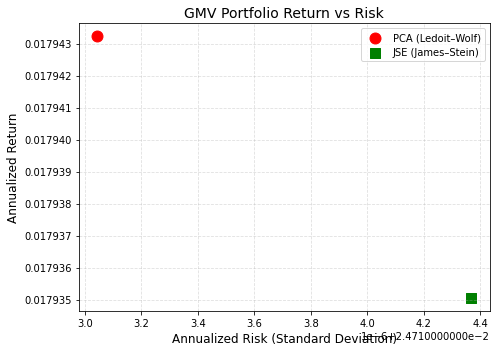

In [72]:
# Plot setup
plt.figure(figsize=(7, 5))

# Plot the two GMV portfolios
plt.scatter(std_pca, ret_pca, color='red', marker='o', s=120, label="PCA (Ledoit–Wolf)")
plt.scatter(std_jse, ret_jse, color='green', marker='s', s=120, label="JSE (James–Stein)")

# Labels, legend, grid
plt.xlabel("Annualized Risk (Standard Deviation)", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.title("GMV Portfolio Return vs Risk", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [81]:
f_c_daily = float(h_c.T @ f)
sigma_c_sq_daily = float(h_c.T @ cov_matrix @ h_c)

f_c_annual = f_c_daily * 252
sigma_c_sq_annual = sigma_c_sq_daily * 252
sigma_c_annual = np.sqrt(sigma_c_sq_annual)

In [ ]:
print("Annualized Return (MVP):", f_c_annual)
print("Annualized Variance:", sigma_c_sq_annual)
print("Annualized Std Dev:", sigma_c_annual)
print("Sum of Weights:", np.sum(h_c))

Annualized Return (MVP): 0.09410279672352803
Annualized Variance: 0.011670939038393082
Annualized Std Dev: 0.10803212040126345
Sum of Weights: 1.0000000000000002


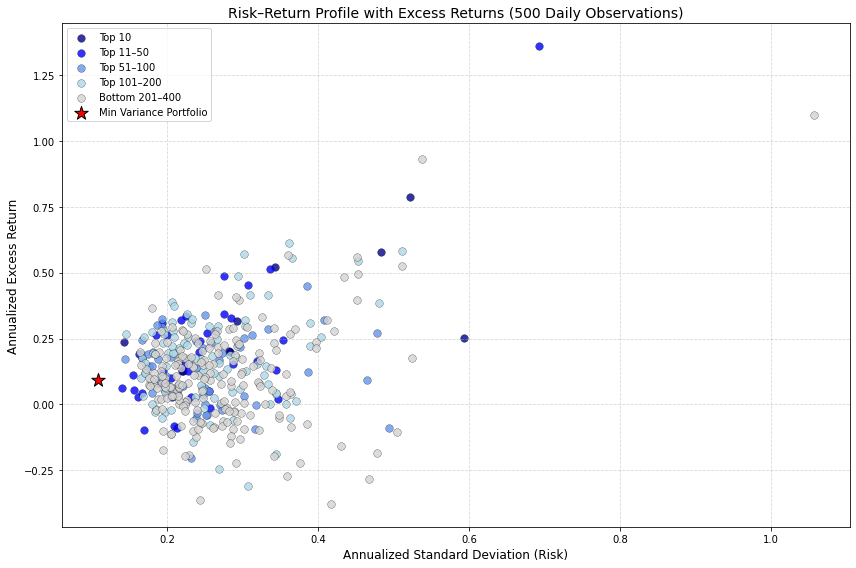

In [67]:
# Individual stats
individual_returns_annual = excess_returns.mean(axis=1) * 252
individual_std_annual = np.sqrt(np.diag(cov_matrix) * 252)

# Min Var Portfolio
f_c_annual = float(h_c.T @ f) * 252
sigma_c_annual = np.sqrt(float(h_c.T @ cov_matrix @ h_c) * 252)

# Get ticker labels
tickers = np.array(top_400_tickers)

# Weight groups
groups = {
    "Top 10": np.arange(0, 10),
    "Top 11–50": np.arange(10, 50),
    "Top 51–100": np.arange(50, 100),
    "Top 101–200": np.arange(100, 200),
    "Bottom 201–400": np.arange(200, 400)
}
colors = ['darkblue', 'blue', 'cornflowerblue', 'lightblue', 'lightgray']

# Plot
plt.figure(figsize=(12, 8))

for (label, indices), color in zip(groups.items(), colors):
    plt.scatter(
        individual_std_annual[indices],
        individual_returns_annual[indices],
        color=color,
        label=label,
        alpha=0.8,
        edgecolor='k',
        linewidth=0.3,
        s=60
    )

# MVP point
plt.scatter(
    sigma_c_annual, f_c_annual,
    color='red', marker='*', s=200,
    label='Min Variance Portfolio', edgecolor='black'
)

# Labels and formatting
plt.xlabel("Annualized Standard Deviation (Risk)", fontsize=12)
plt.ylabel("Annualized Excess Return", fontsize=12)
plt.title("Risk–Return Profile with Excess Returns (500 Daily Observations)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


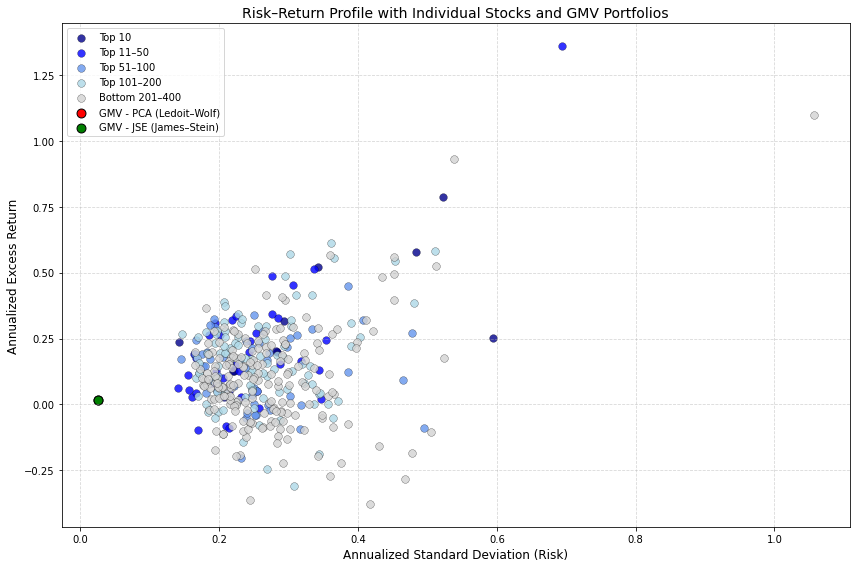

In [84]:
# Individual stats
individual_returns_annual = excess_returns.mean(axis=1) * 252
individual_variances_annual = np.diag(cov_matrix) * 252

# MVP stats (already computed above)
f_c_annual = float(h_c.T @ f) * 252
sigma_c_sq_annual = float(h_c.T @ cov_matrix @ h_c) * 252
sigma_c_annual = np.sqrt(sigma_c_sq_annual)
weight_sum = np.sum(h_c)

# Summary table
summary_data = {
    "Metric": [
        "Minimum Variance Portfolio Return",
        "Minimum Variance Portfolio Variance",
        "Minimum Variance Portfolio Std Dev",
        "Sum of Portfolio Weights",
        "Max Individual Stock Return",
        "Min Individual Stock Return",
        "Max Individual Stock Variance",
        "Min Individual Stock Variance"
    ],
    "Value": [
        f_c_annual,
        sigma_c_sq_annual,
        sigma_c_annual,
        weight_sum,
        individual_returns_annual.max(),
        individual_returns_annual.min(),
        individual_variances_annual.max(),
        individual_variances_annual.min()
    ]
}

summary_df = pd.DataFrame(summary_data)

# Print as LaTeX
latex_table = summary_df.to_latex(index=False, float_format="%.6f")
print(latex_table)

\begin{tabular}{lr}
\toprule
                             Metric &     Value \\
\midrule
  Minimum Variance Portfolio Return &  0.084869 \\
Minimum Variance Portfolio Variance &  0.000950 \\
 Minimum Variance Portfolio Std Dev &  0.030828 \\
           Sum of Portfolio Weights &  1.000000 \\
        Max Individual Stock Return &  1.359834 \\
        Min Individual Stock Return & -0.378068 \\
      Max Individual Stock Variance &  1.116759 \\
      Min Individual Stock Variance &  0.019707 \\
\bottomrule
\end{tabular}



C:\Users\DELL\AppData\Local\Temp\ipykernel_19940\44638441.py:38: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = summary_df.to_latex(index=False, float_format="%.6f")


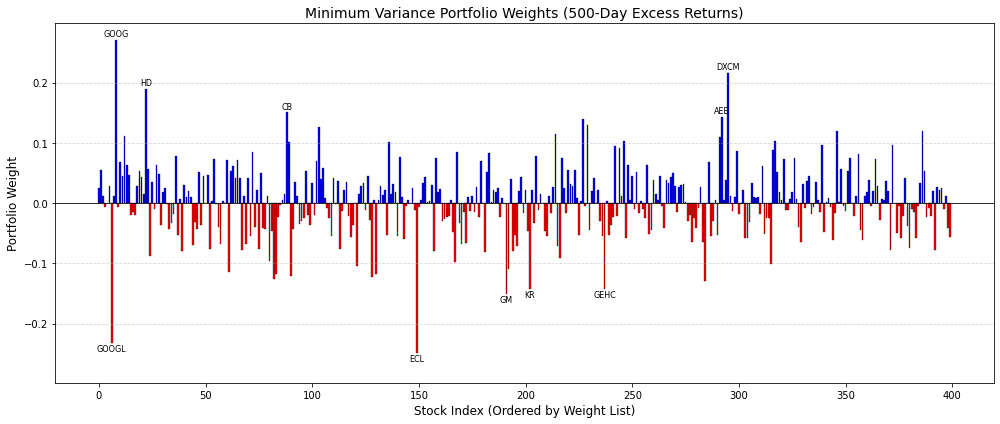

In [85]:
# Flatten weights just in case
h_c = h_c.flatten()
x = np.arange(len(h_c))
colors = ['blue' if w > 0 else 'red' for w in h_c]

plt.figure(figsize=(14, 6))
bars = plt.bar(x, h_c, color=colors, edgecolor='black', linewidth=0.3)

# Label top 10 absolute weights
top_10_indices = np.argsort(np.abs(h_c))[-10:]
for i in top_10_indices:
    plt.text(
        x[i],
        h_c[i] + (0.002 if h_c[i] > 0 else -0.002),
        tickers[i],
        ha='center',
        va='bottom' if h_c[i] > 0 else 'top',
        fontsize=8,
        rotation=0
    )

# Symmetric y-axis
ymax = np.max(np.abs(h_c))
plt.ylim(-ymax * 1.1, ymax * 1.1)

# Final styling
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Minimum Variance Portfolio Weights (500-Day Excess Returns)", fontsize=14)
plt.xlabel("Stock Index (Ordered by Weight List)", fontsize=12)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()